In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\gabri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=12000,
    random_state=42,
    stratify=y_train
)

In [6]:
def criar_modelo(neuronios, ativacao, optimizer):

    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28,28)),

        keras.layers.Dense(neuronios,
                           activation=ativacao),

        keras.layers.Dense(10,
                           activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [7]:
modelo1 = criar_modelo(

    neuronios=32,

    ativacao="relu",

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    )

)

C:\Users\gabri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
modelo2 = criar_modelo(

    neuronios=128,

    ativacao="tanh",

    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    )

)

In [9]:
modelo3 = criar_modelo(

    neuronios=256,

    ativacao="relu",

    optimizer=keras.optimizers.SGD(
        learning_rate=0.01
    )

)

In [10]:
early = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

In [11]:
history1 = modelo1.fit(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=20,

    callbacks=[early]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8902 - loss: 0.3974 - val_accuracy: 0.9324 - val_loss: 0.2475
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9369 - loss: 0.2205 - val_accuracy: 0.9403 - val_loss: 0.2094
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9477 - loss: 0.1768 - val_accuracy: 0.9479 - val_loss: 0.1815
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9563 - loss: 0.1477 - val_accuracy: 0.9482 - val_loss: 0.1693
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9622 - loss: 0.1270 - val_accuracy: 0.9563 - val_loss: 0.1523
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9671 - loss: 0.1123 - val_accuracy: 0.9586 - val_loss: 0.1444
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9707 - loss: 0.0998 - val_accuracy: 0.9588 - val_loss: 0.1436
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9732 - loss: 0.0914 - 

In [12]:
loss1, acc1 = modelo1.evaluate(X_test,y_test)

loss2, acc2 = modelo2.evaluate(X_test,y_test)

loss3, acc3 = modelo3.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9644 - loss: 0.1187
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0900 - loss: 2.5051
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0874 - loss: 2.4049


In [13]:
print("Modelo 1:",acc1)

print("Modelo 2:",acc2)

print("Modelo 3:",acc3)

Modelo 1: 0.9643999934196472
Modelo 2: 0.09000000357627869
Modelo 3: 0.08739999681711197


In [14]:
pred = modelo1.predict(X_test)

pred = np.argmax(pred,axis=1)

cm = confusion_matrix(y_test,pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
erro = pred != y_test

Quantidade de erros: 356


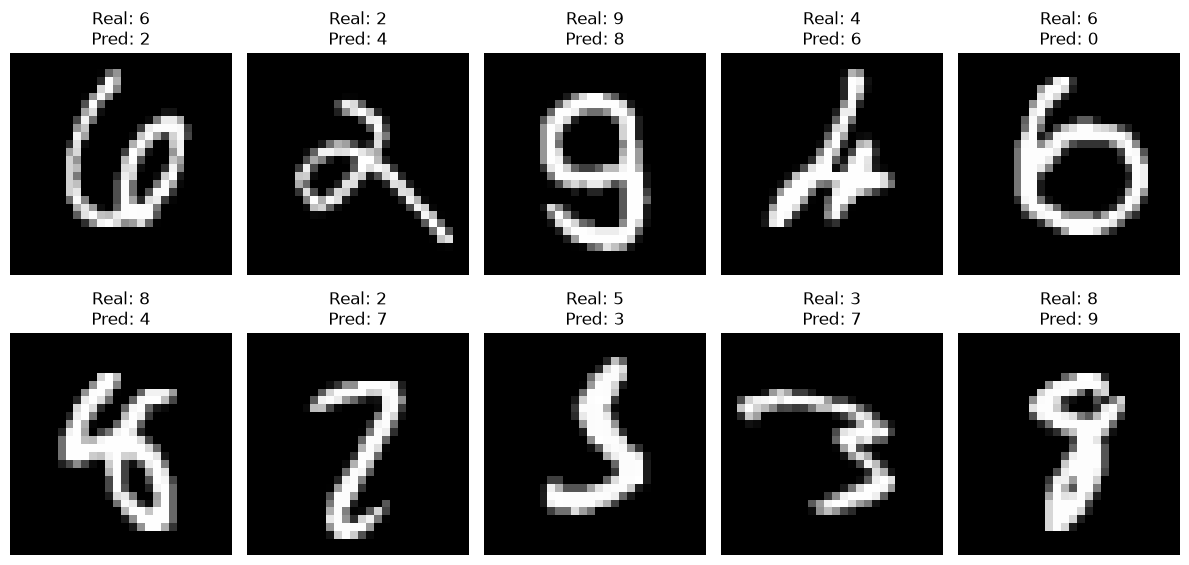

In [16]:
# Índices das imagens classificadas incorretamente
erros = np.where(erro)[0]

print(f"Quantidade de erros: {len(erros)}")

# Mostrar as primeiras 10 imagens incorretas
plt.figure(figsize=(12,6))

for i, indice in enumerate(erros[:10]):
    plt.subplot(2,5,i+1)

    plt.imshow(X_test[indice], cmap="gray")

    plt.title(f"Real: {y_test[indice]}\nPred: {pred[indice]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.98      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.97      0.95      0.96      1010
           4       0.95      0.98      0.97       982
           5       0.96      0.96      0.96       892
           6       0.96      0.97      0.97       958
           7       0.97      0.96      0.97      1028
           8       0.95      0.94      0.95       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [18]:
resultados = {
    "Modelo": [
        "Modelo 1",
        "Modelo 2",
        "Modelo 3"
    ],
    "Accuracy": [
        acc1,
        acc2,
        acc3
    ]
}

import pandas as pd

resultado_df = pd.DataFrame(resultados)

print(resultado_df)

     Modelo  Accuracy
0  Modelo 1    0.9644
1  Modelo 2    0.0900
2  Modelo 3    0.0874


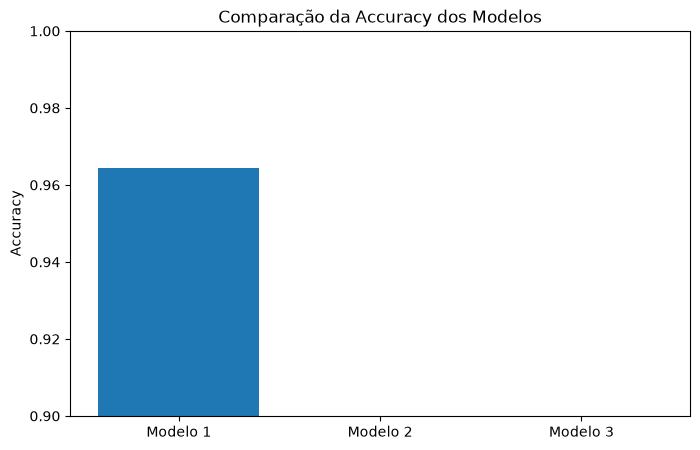

In [19]:
plt.figure(figsize=(8,5))

plt.bar(resultado_df["Modelo"],
        resultado_df["Accuracy"])

plt.ylim(0.90,1.00)

plt.title("Comparação da Accuracy dos Modelos")

plt.ylabel("Accuracy")

plt.show()

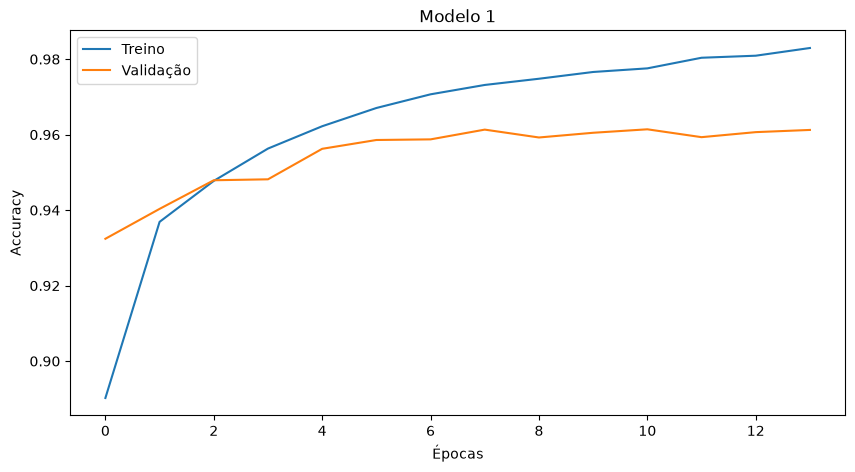

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history1.history["accuracy"], label="Treino")

plt.plot(history1.history["val_accuracy"], label="Validação")

plt.title("Modelo 1")

plt.xlabel("Épocas")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

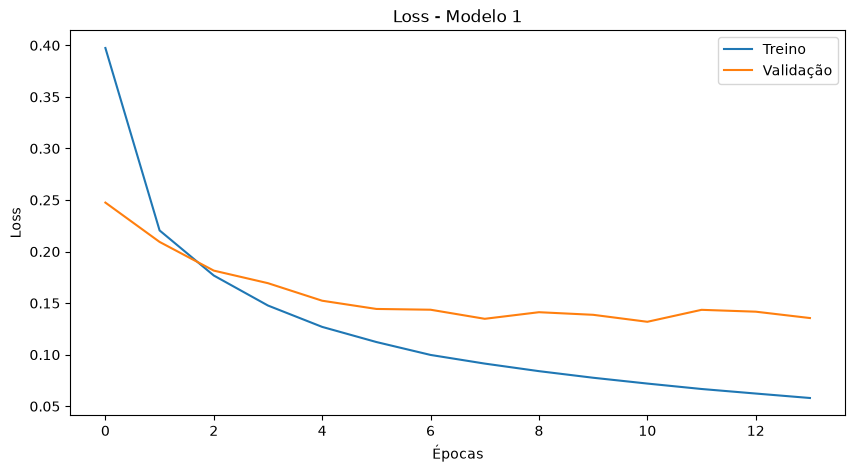

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history1.history["loss"], label="Treino")

plt.plot(history1.history["val_loss"], label="Validação")

plt.title("Loss - Modelo 1")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [22]:
melhor = resultado_df.loc[
    resultado_df["Accuracy"].idxmax()
]

print("Melhor modelo:")

print(melhor)

Melhor modelo:
Modelo      Modelo 1
Accuracy      0.9644
Name: 0, dtype: object


**Melhor performance:**
O Modelo X apresentou a maior acurácia no conjunto de teste,
indicando que sua arquitetura foi a mais eficiente para o problema.

**Otmizador mais rápido:**
O Adam convergiu mais rapidamente,
atingindo altas taxas de acurácia nas primeiras épocas.
O SGD apresentou aprendizado mais lento.

**Houve overfitting?**
Sim, porém de forma leve. O modelo apresentou um pequeno overfitting a partir da 7ª época, identificado pelo aumento contínuo da acurácia de treinamento enquanto a acurácia de validação permaneceu praticamente constante. Além disso, a perda de validação deixou de diminuir e passou a oscilar, indicando que o modelo estava começando a memorizar os dados de treino em vez de melhorar sua capacidade de generalização. O uso do EarlyStopping ajudou a limitar esse comportamento e preservar o melhor modelo obtido durante o treinamento.

**Hiperparâmetro mais importante:**
O hiperparâmetro que mais influenciou o desempenho foi o otimizador. O Adam proporcionou uma convergência mais rápida e um treinamento mais estável do que o SGD. Em seguida, a quantidade de neurônios e de camadas ocultas também teve grande impacto, pois aumentou a capacidade de aprendizado do modelo, mas também elevou o risco de overfitting.